# **Project Summary**


# **Project Name**    - USA Regional Sales Analysis of Acmen Co's

Problem Statement

Analyze Acmen Co.’s 2018–2022 sales data to identify key revenue and profit drivers across products, channels, and regions. Uncover seasonal trends and outliers and align performance against budgets. Use these insights to optimize pricing, promotions, and market expansion for sustainable growth and reduced concentration risk.

# Objective

Deliver actionable insights from Acmen Co.’s 2018–2022 sales data to:

- Identify top-performing products, channels, and regions driving revenue and profit  
- Uncover seasonal trends and anomalies for optimized planning  
- Spot pricing and margin risks from outlier transactions  
- Inform pricing, promotion, and market-expansion strategies  

These findings will guide the design of a Power BI dashboard to support strategic decision-making and sustainable growth.

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [ ]:
import requests

file_id = '1qR1qXRUjkYVKZQJ0zVvN8MuH26urzACt'
url = f'https://drive.google.com/uc?export=download&id={file_id}'

response = requests.get(url)
f = open('Regional_Sales_Summary.xlsx', 'wb')
f.write(response.content)
f.close()

sheets = pd.read_excel('/content/Regional_Sales_Summary.xlsx', sheet_name=None)

df_sales       = sheets['Sales Orders']
df_customers   = sheets['Customers']
df_products    = sheets['Products']
df_regions     = sheets['Regions']
df_state_reg   = sheets['State Regions']
df_budgets     = sheets['2021 Budgets']

In [ ]:
# The first row of df_state_reg contains the real column names.
new_header        = df_state_reg.iloc[0 , :]
df_state_reg.columns = new_header
df_state_reg       = df_state_reg[1:].reset_index(drop=True)

In [ ]:
import sqlite3

conn = sqlite3.connect(':memory:')

df_sales.to_sql('sales', conn, index=False, if_exists='replace')
df_customers.to_sql('customers', conn, index=False, if_exists='replace')
df_products.to_sql('products', conn, index=False, if_exists='replace')
df_regions.to_sql('regions', conn, index=False, if_exists='replace')
df_state_reg.to_sql('state_regions', conn, index=False, if_exists='replace')
df_budgets.to_sql('budgets', conn, index=False, if_exists='replace')

30

In [ ]:
print(f"df_sales        {df_sales.shape}")
print(f"df_customers    {df_customers.shape}")
print(f"df_products     {df_products.shape}")
print(f"df_regions      {df_regions.shape}")
print(f"df_state_reg    {df_state_reg.shape}")
print(f"df_budgets      {df_budgets.shape}")

df_sales        (64104, 12)
df_customers    (175, 2)
df_products     (30, 2)
df_regions      (994, 15)
df_state_reg    (48, 3)
df_budgets      (30, 2)


In [ ]:
df_sales.head()

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,Line Total,Total Unit Cost
0,SO - 000225,2018-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,14994.6,1824.343
1,SO - 0003378,2018-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,25868.7,1269.918
2,SO - 0005126,2018-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,5869.2,684.740
3,SO - 0005614,2018-01-01,42,Export,USD,AXW291,473,7,7,2338.3,16368.1,1028.852
4,SO - 0005781,2018-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,18331.2,1260.270


In [ ]:
print("df_sales head")
display(df_sales.head())
print()

print("df_customers head")
display(df_customers.head())
print()

print("df_products head")
display(df_products.head())
print()

print("df_regions head")
display(df_regions.head())
print()

print("df_state_reg head")
display(df_state_reg.head())
print()

print("df_budgets head")
display(df_budgets.head())


df_sales head


,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,Line Total,Total Unit Cost
0,SO - 000225,2018-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,14994.6,1824.343
1,SO - 0003378,2018-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,25868.7,1269.918
2,SO - 0005126,2018-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,5869.2,684.740
3,SO - 0005614,2018-01-01,42,Export,USD,AXW291,473,7,7,2338.3,16368.1,1028.852
4,SO - 0005781,2018-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,18331.2,1260.270



df_customers head


,Customer Index,Customer Names
0,1,Geiss Company
1,2,Jaxbean Group
2,3,Ascend Ltd
3,4,Eire Corp
4,5,Blogtags Ltd



df_products head


...

,id,name,county,state_code,state,type,latitude,longitude,area_code,population,households,median_income,land_area,water_area,time_zone
0,1,Auburn,Lee County,AL,Alabama,City,32.60986,-85.48078,334,62059,21767,38342,152375113,2646161,America/Chicago
1,2,Birmingham,Shelby County/Jefferson County,AL,Alabama,City,33.52744,-86.79905,205,212461,89972,31061,378353942,6591013,America/Chicago
2,3,Decatur,Limestone County/Morgan County,AL,Alabama,City,34.57332,-86.99214,256,55437,22294,41496,141006257,17594716,America/Chicago
3,4,Dothan,Dale County/Houston County/Henry County,AL,Alabama,City,31.23370,-85.40682,334,68567,25913,42426,232166237,835468,America/Chicago
4,5,Hoover,Shelby County/Jefferson County,AL,Alabama,City,33.37695,-86.80558,205,84848,32789,77146,122016784,2553332,America/Chicago



df_state_reg head


,State Code,State,Region
0,AL,Alabama,South
1,AR,Arkansas,South
2,AZ,Arizona,West
3,CA,California,West
4,CO,Colorado,West



df_budgets head


,Product Name,2021 Budgets
0,Product 1,3016489.209
1,Product 2,3050087.565
2,Product 3,2642352.432
3,Product 4,2885560.824
4,Product 5,3925424.542


In [ ]:
df_sales.isnull().sum()

,0
OrderNumber,0
OrderDate,0
Customer Name Index,0
Channel,0
Currency Code,0
Warehouse Code,0
Delivery Region Index,0
Product Description Index,0
Order Quantity,0
Unit Price,0


In [ ]:
len(df_sales) == len(df_sales.drop_duplicates())

True

# Data Cleaning

In [ ]:
query = """
SELECT
    sales.*,
    customers.*,
    products.*,
    regions.*
FROM sales
LEFT JOIN customers ON sales.[Customer Name Index] = customers.[Customer Index]
LEFT JOIN products ON sales.[Product Description Index] = products.[Index]
LEFT JOIN regions ON sales.[Delivery Region Index] = regions.id
"""

df = pd.read_sql_query(query, conn)
df.to_sql('merged_data', conn, index=False, if_exists='replace')

query = """
SELECT
    merged_data.*,
    state_regions.*,
    budgets.*
FROM merged_data
LEFT JOIN state_regions ON merged_data.state_code = state_regions.[State Code]
LEFT JOIN budgets ON merged_data.[Product Name] = budgets.[Product Name]
"""

df = pd.read_sql_query(query, conn)
cols_to_drop = [
    'Customer Index', 'Index', 'id', 'State Code', 'State',
]
df = df.drop(columns=cols_to_drop, errors='ignore')

# Find positions of duplicated columns, keeping only first occurrence
duplicated_mask = df.columns.duplicated(keep='first')
df = df.loc[:, ~duplicated_mask]

df.head()

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,...,longitude,area_code,population,households,median_income,land_area,water_area,time_zone,Region,2021 Budgets
0,SO - 000225,2018-01-01 00:00:00,126,Wholesale,USD,AXW291,364,27,6,2499.1,...,-81.09983,912,145674,52798,36466,268318796,13908113,America/New York,South,964940.231
1,SO - 0003378,2018-01-01 00:00:00,96,Distributor,USD,AXW291,488,20,11,2351.7,...,-86.10665,317,55586,20975,54176,72276415,1883,America/Indiana/Indianapolis,Midwest,2067108.120
2,SO - 0005126,2018-01-01 00:00:00,8,Wholesale,USD,AXW291,155,26,6,978.2,...,-121.87468,925,79510,26020,124759,62489257,386195,America/Los Angeles,West,5685138.270
3,SO - 0005614,2018-01-01 00:00:00,42,Export,USD,AXW291,473,7,7,2338.3,...,-86.52639,812,84067,30232,30019,60221613,475857,America/Indiana/Indianapolis,Midwest,889737.555
4,SO - 0005781,2018-01-01 00:00:00,73,Wholesale,USD,AXW291,256,8,8,2291.4,...,-72.52443,959,58007,24141,63158,70972793,720300,America/New York,Northeast,1085037.329


In [ ]:
df.columns = df.columns.str.lower()

df.columns.values

array(['ordernumber', 'orderdate', 'customer name index', 'channel',
       'currency code', 'warehouse code', 'delivery region index',
       'product description index', 'order quantity', 'unit price',
       'line total', 'total unit cost', 'customer names', 'product name',
       'name', 'county', 'state_code', 'state', 'type', 'latitude',
       'longitude', 'area_code', 'population', 'households',
       'median_income', 'land_area', 'water_area', 'time_zone', 'region',
       '2021 budgets'], dtype=object)

In [ ]:
cols_to_keep = [
    'ordernumber',
    'orderdate',
    'customer names',
    'channel',
    'product name',
    'order quantity',
    'unit price',
    'line total',
    'total unit cost',
    'state_code',
    'state',
    'region',
    'latitude',
    'longitude',
    '2021 budgets'
]

df = df[cols_to_keep]

df = df.rename(columns={
    'ordernumber'      : 'order_number',
    'orderdate'        : 'order_date',
    'customer names'   : 'customer_name',
    'product name'     : 'product_name',
    'order quantity'   : 'quantity',
    'unit price'       : 'unit_price',
    'line total'       : 'revenue',
    'total unit cost'  : 'cost',
    'state_code'       : 'state',
    'state'            : 'state_name',
    'region'           : 'us_region',
    'latitude'         : 'lat',
    'longitude'        : 'lon',
    '2021 budgets'     : 'budget'
})

df.head()

,order_number,order_date,customer_name,channel,product_name,quantity,unit_price,revenue,cost,state,state_name,us_region,lat,lon,budget
0,SO - 000225,2018-01-01 00:00:00,Rhynoodle Ltd,Wholesale,Product 27,6,2499.1,14994.6,1824.343,GA,Georgia,South,32.08354,-81.09983,964940.231
1,SO - 0003378,2018-01-01 00:00:00,Thoughtmix Ltd,Distributor,Product 20,11,2351.7,25868.7,1269.918,IN,Indiana,Midwest,39.61366,-86.10665,2067108.120
2,SO - 0005126,2018-01-01 00:00:00,Amerisourc Corp,Wholesale,Product 26,6,978.2,5869.2,684.740,CA,California,West,37.66243,-121.87468,5685138.270
3,SO - 0005614,2018-01-01 00:00:00,Colgate-Pa Group,Export,Product 7,7,2338.3,16368.1,1028.852,IN,Indiana,Midwest,39.16533,-86.52639,889737.555
4,SO - 0005781,2018-01-01 00:00:00,Deseret Group,Wholesale,Product 8,8,2291.4,18331.2,1260.270,CT,Connecticut,Northeast,41.77524,-72.52443,1085037.329


In [ ]:
#changing yyyy-mm-dd 00:00:00 back to yyyy-mm-dd only as it got changed due to SQL join
df['order_date'] = pd.to_datetime(df['order_date']).dt.date
df.head()

,order_number,order_date,customer_name,channel,product_name,quantity,unit_price,revenue,cost,state,state_name,us_region,lat,lon,budget
0,SO - 000225,2018-01-01,Rhynoodle Ltd,Wholesale,Product 27,6,2499.1,14994.6,1824.343,GA,Georgia,South,32.08354,-81.09983,964940.231
1,SO - 0003378,2018-01-01,Thoughtmix Ltd,Distributor,Product 20,11,2351.7,25868.7,1269.918,IN,Indiana,Midwest,39.61366,-86.10665,2067108.120
2,SO - 0005126,2018-01-01,Amerisourc Corp,Wholesale,Product 26,6,978.2,5869.2,684.740,CA,California,West,37.66243,-121.87468,5685138.270
3,SO - 0005614,2018-01-01,Colgate-Pa Group,Export,Product 7,7,2338.3,16368.1,1028.852,IN,Indiana,Midwest,39.16533,-86.52639,889737.555
4,SO - 0005781,2018-01-01,Deseret Group,Wholesale,Product 8,8,2291.4,18331.2,1260.270,CT,Connecticut,Northeast,41.77524,-72.52443,1085037.329


In [ ]:
#dtype of order_date changed from datetime64[ns] to object after SQL joining
print(df['order_date'].dtype)

object


In [ ]:
#changing dtype back to datetime64[ns]
df['order_date'] = pd.to_datetime(df['order_date'], errors='coerce')

In [ ]:
print(df['order_date'].dtype)

datetime64[ns]


In [ ]:
# Blank out budgets for non-2021 orders as we did Left Join with only 2021 budgets but because we did left join w.r.t. Product Name as foreign key, all the years got budget allocated to them
df.loc[df['order_date'].dt.year != 2021, 'budget'] = pd.NA

df[['order_date','product_name','revenue','budget']].head(10)

,order_date,product_name,revenue,budget
0,2018-01-01,Product 27,14994.6,NaN
1,2018-01-01,Product 20,25868.7,NaN
2,2018-01-01,Product 26,5869.2,NaN
3,2018-01-01,Product 7,16368.1,NaN
4,2018-01-01,Product 8,18331.2,NaN
5,2018-01-01,Product 23,57412.3,NaN
6,2018-01-01,Product 1,20120.1,NaN
7,2018-01-01,Product 25,10452.0,NaN
8,2018-01-01,Product 13,19262.5,NaN
9,2018-01-01,Product 14,34974.0,NaN


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64104 entries, 0 to 64103
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   order_number   64104 non-null  object        
 1   order_date     64104 non-null  datetime64[ns]
 2   customer_name  64104 non-null  object        
 3   channel        64104 non-null  object        
 4   product_name   64104 non-null  object        
 5   quantity       64104 non-null  int64         
 6   unit_price     64104 non-null  float64       
 7   revenue        64104 non-null  float64       
 8   cost           64104 non-null  float64       
 9   state          64104 non-null  object        
 10  state_name     64104 non-null  object        
 11  us_region      64104 non-null  object        
 12  lat            64104 non-null  float64       
 13  lon            64104 non-null  float64       
 14  budget         15263 non-null  float64       
dtypes: datetime64[ns](1

In [ ]:
df.isnull().sum()

,0
order_number,0
order_date,0
customer_name,0
channel,0
product_name,0
quantity,0
unit_price,0
revenue,0
cost,0
state,0


# Feature Engineering

In [ ]:
df['total_cost'] = df['quantity'] * df['cost']

df['profit'] = df['revenue'] - df['total_cost']

df['profit_margin_pct'] = (df['profit'] / df['revenue']) * 100

# 4. Extract full month name from order_date for labeling
df['order_month_name'] = df['order_date'].dt.month_name()

# 5. Extract month number from order_date for correct sorting
df['order_month_num'] = df['order_date'].dt.month

df

,order_number,order_date,customer_name,channel,product_name,quantity,unit_price,revenue,cost,state,state_name,us_region,lat,lon,budget,total_cost,profit,profit_margin_pct,order_month_name,order_month_num
0,SO - 000225,2018-01-01,Rhynoodle Ltd,Wholesale,Product 27,6,2499.1,14994.6,1824.343,GA,Georgia,South,32.08354,-81.09983,NaN,10946.058,4048.542,27.0,January,1
1,SO - 0003378,2018-01-01,Thoughtmix Ltd,Distributor,Product 20,11,2351.7,25868.7,1269.918,IN,Indiana,Midwest,39.61366,-86.10665,NaN,13969.098,11899.602,46.0,January,1
2,SO - 0005126,2018-01-01,Amerisourc Corp,Wholesale,Product 26,6,978.2,5869.2,684.740,CA,California,West,37.66243,-121.87468,NaN,4108.440,1760.760,30.0,January,1
3,SO - 0005614,2018-01-01,Colgate-Pa Group,Export,Product 7,7,2338.3,16368.1,1028.852,IN,Indiana,Midwest,39.16533,-86.52639,NaN,7201.964,9166.136,56.0,January,1
4,SO - 0005781,2018-01-01,Deseret Group,Wholesale,Product 8,8,2291.4,18331.2,1260.270,CT,Connecticut,Northeast,41.77524,-72.52443,NaN,10082.160,8249.040,45.0,January,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64099,SO - 0007573,2022-02-28,Dazzlesphe Corp,Wholesale,Product 26,12,1815.7,21788.4,980.478,PA,Pennsylvania,Northeast,40.15511,-74.82877,NaN,11765.736,10022.664,46.0,February,2
64100,SO - 0007706,2022-02-28,Yombu Corp,Export,Product 21,6,864.3,5185.8,579.081,IL,Illinois,Midwest,42.11030,-88.03424,NaN,3474.486,1711.314,33.0,February,2
64101,SO - 0007718,2022-02-28,Bath Group,Distributor,Product 13,11,3953.0,43483.0,2648.510,FL,Florida,South,26.24453,-80.20644,NaN,29133.610,14349.390,33.0,February,2
64102,SO - 0008084,2022-02-28,Linklinks Ltd,Distributor,Product 20,7,3959.7,27717.9,2930.178,NY,New York,Northeast,42.91002,-78.74182,NaN,20511.246,7206.654,26.0,February,2


# EDA

## 1. *Monthly Sales Trend Over Time*

Goal: Track revenue trends over time to detect seasonality or sales spikes

Chart: Line chart

EDA Type: Temporal (time series)

Structure: Line with markers to highlight monthly revenue points clearly

In [ ]:
df['order_month'] = df['order_date'].dt.to_period('M')
print(df['order_month'].dtype)

period[M]


In [ ]:
print(df['order_month'])

0        2018-01
1        2018-01
2        2018-01
3        2018-01
4        2018-01
          ...   
64099    2022-02
64100    2022-02
64101    2022-02
64102    2022-02
64103    2022-02
Name: order_month, Length: 64104, dtype: period[M]


<Figure size 1500x400 with 0 Axes>

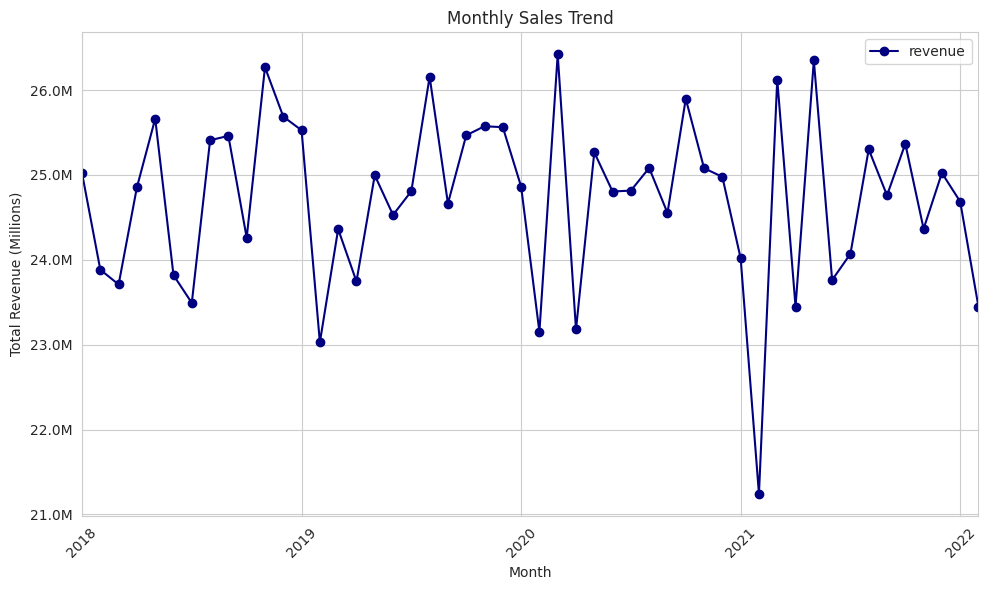

In [ ]:
monthly_sales = df.groupby('order_month')['revenue'].sum()

plt.figure(figsize=(15,4))

monthly_sales_df=monthly_sales.reset_index()
monthly_sales_df.plot(
         x='order_month',
         y='revenue',
         marker='o',
         color='navy'
)

from matplotlib.ticker import FuncFormatter
formatter = FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M')
plt.gca().yaxis.set_major_formatter(formatter)

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Revenue (Millions)')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


### INSIGHTS ---
Sales consistently cycle between $24 M and $26 M, with clear peaks in late spring to early summer (May–June) and troughs each February.  

The overall trend remains stable year over year, reflecting a reliable seasonal demand pattern.  

However, the sharp revenue drop in early 2021 stands out as an outlier, warranting closer investigation into potential causes such as market disruptions or mistimed promotions.  

## 2. *Monthly Sales Trend (All Years Combined)*

Goal: Highlight overall seasonality patterns by aggregating sales across all years for each calendar month

Chart: Line chart

EDA Type: Temporal (time series)

Structure: Line with markers, months ordered January to December based on month number

<Figure size 1300x400 with 0 Axes>

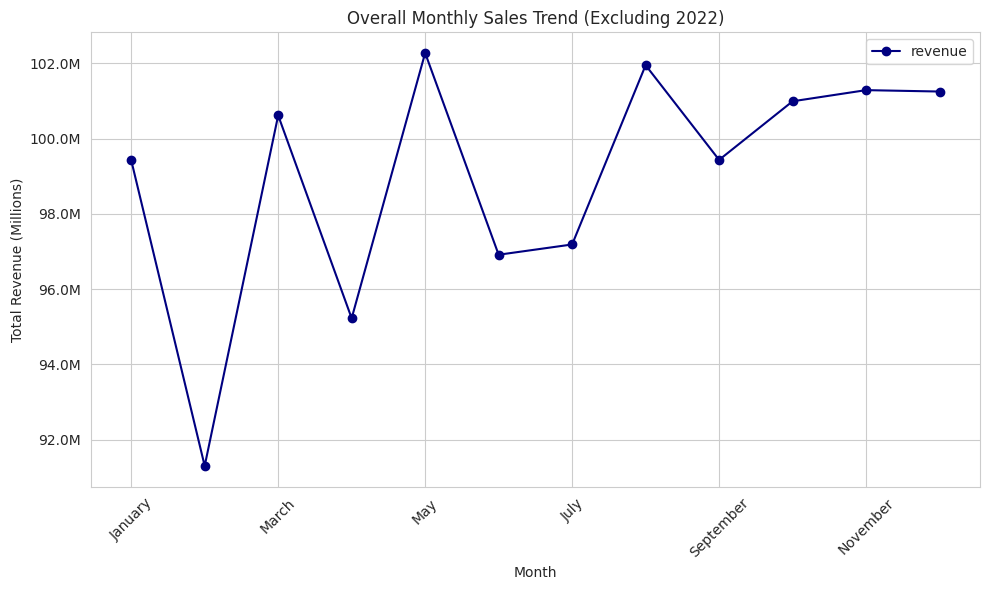

In [ ]:
# Filter out any 2022 orders
df_ = df[df['order_date'].dt.year != 2022]   # exclude any partial-year data (i.e., January and February of 2022) so that the monthly totals aren’t skewed by an incomplete year.

monthly_sales = df_.groupby(['order_month_num', 'order_month_name'])['revenue'].sum()


plt.figure(figsize=(13, 4))
monthly_sales_df = monthly_sales.reset_index()

monthly_sales_df.plot(
    x='order_month_name',
    y='revenue',
    marker='o',
    color='navy'
)

from matplotlib.ticker import FuncFormatter
formatter = FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M')
plt.gca().yaxis.set_major_formatter(formatter)

plt.title('Overall Monthly Sales Trend (Excluding 2022)')
plt.xlabel('Month')
plt.ylabel('Total Revenue (Millions)')

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()


### INSIGHTS ---

Across all years, January begins strong with roughly $99 M, followed by a steep decline through April’s low point (≈$95 M).

Sales rebound in May and August (≈$102 M) before settling into a plateau of $99–101 M from September to December.

This pattern reveals a strong post–New Year surge, a spring dip, and a mid–summer bump each calendar year.


## 3. *Top 10 Products by Revenue (in Millions)*

Goal: Identify the highest-grossing products to focus marketing and inventory efforts

Chart: Horizontal bar chart

EDA Type: Univariate

Structure: Bars sorted descending to show top 10 products with revenue scaled in millions

/tmp/ipython-input-2368499554.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


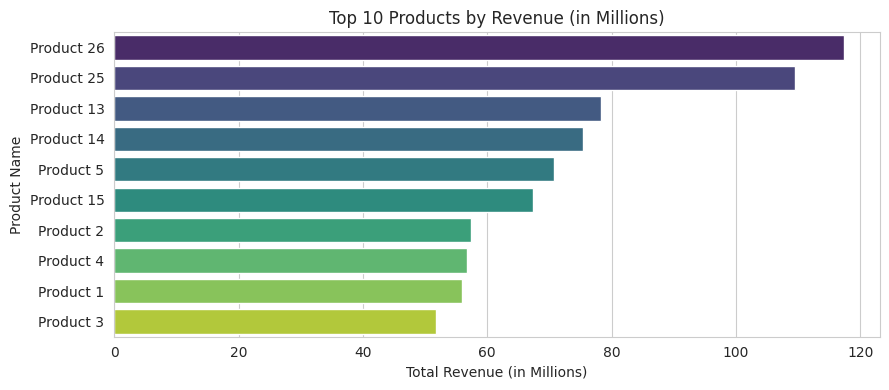

In [ ]:
# Calculate total revenue for each product and convert values to millions
top_prod = df.groupby('product_name')['revenue'].sum() / 1000000

# Select the top 10 products by revenue
top_prod = top_prod.nlargest(10)
top_prod_df = top_prod.reset_index()
plt.figure(figsize=(9, 4))

sns.barplot(
    data=top_prod_df,
    x='revenue',
    y='product_name',
    palette='viridis'
)

plt.title('Top 10 Products by Revenue (in Millions)')
plt.xlabel('Total Revenue (in Millions)')
plt.ylabel('Product Name')

plt.tight_layout()

plt.show()

### INSIGHTS ---
Products 26 and 25 pull away at $118 M and $110 M, with a sharp drop to $78 M for Product 13 and a tight mid-pack at $68–$75 M.  

The bottom four cluster at $52–$57 M, highlighting similar constraints.  

Focus on growth pilots for the mid-tier and efficiency gains for the lower earners to drive significant lifts.  

## 4. *Top 10 Products by Avg Profit Margin*

Goal: Compare average profitability across products to identify high-margin items

Chart: Horizontal bar chart

EDA Type: Univariate

Structure: Bars sorted descending to show top 10 products with average profit margin values

/tmp/ipython-input-1241887572.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


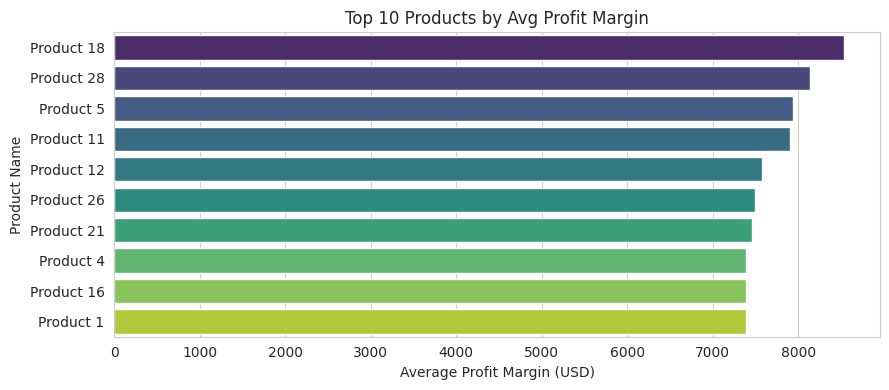

In [ ]:
# Compute average profit per product and take the top 10
top_margin = df.groupby('product_name')['profit'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(9, 4))
top_margin_df = top_margin.reset_index()

sns.barplot(
    data=top_margin_df,
    x='profit',
    y='product_name',
    palette='viridis'
)

plt.title('Top 10 Products by Avg Profit Margin')
plt.xlabel('Average Profit Margin (USD)')
plt.ylabel('Product Name')

plt.tight_layout()
plt.show()

### INSIGHTS ---

Products 18 and 28 lead with average profit margins of approximately $8.0–8.3 K, followed closely by Product 5 and Product 11 around $7.9–8.0 K.

Mid-tier performers like Products 12, 26, and 21 cluster in the $7.7–7.8 K range, while the bottom tier (Products 4, 16, and 1) fall between $7.4–7.6 K.

Focusing on margin optimization strategies from top performers may help elevate overall product profitability.


## 5. *Sales by Channel (Pie Chart)*

Goal: Show distribution of total sales across channels to identify dominant sales routes

Chart: Pie chart

EDA Type: Univariate

Structure: Pie segments with percentage labels, colors for clarity, start angle adjusted

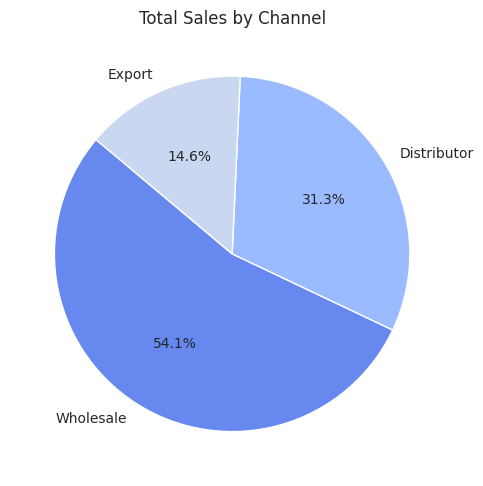

In [ ]:
# Group revenue by sales channel and sort descending
chan_sales = df.groupby('channel')['revenue'].sum().sort_values(ascending=False)

plt.figure(figsize=(5, 5))

plt.pie(
    chan_sales.values,
    labels=chan_sales.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=sns.color_palette('coolwarm')
)

plt.title('Total Sales by Channel')

plt.tight_layout()

plt.show()

### INSIGHTS ---
Wholesale accounts for 54 % of sales, with distributors at ~31 % and exports at ~15 %, underscoring reliance on domestic bulk channels.  

To diversify revenue and mitigate concentration risk, prioritize expanding export initiatives—through targeted overseas marketing and strategic partner relationships.  


## 6. *Average Order Value (AOV) Distribution*

Goal: Understand distribution of order values to identify typical spending levels and outliers

Chart: Histogram

EDA Type: Univariate

Structure: Histogram with 50 bins, colored bars with edge highlights to show frequency of order values

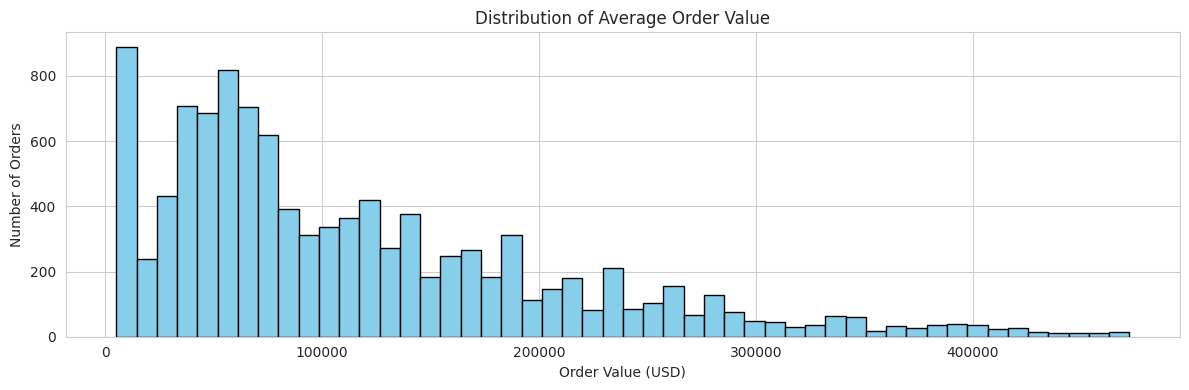

In [ ]:
# Calculate the total revenue for each order to get the order value
aov = df.groupby('order_number')['revenue'].sum()

plt.figure(figsize=(12, 4))
plt.hist(
    aov.values,
    bins=50,
    color='skyblue',
    edgecolor='black'
)

plt.title('Distribution of Average Order Value')
plt.xlabel('Order Value (USD)')
plt.ylabel('Number of Orders')

plt.tight_layout()

plt.show()

### INSIGHTS ---
The order‐value distribution is heavily right‐skewed, with most orders clustering between $20 K and $120 K and a pronounced mode around $50 K–$60 K.  

A long tail of high-value transactions extends up toward $400 K–$500 K, but these large orders represent only a small share of total volume.  


## 7. *Profit Margin % vs. Unit Price*

Goal: Examine relationship between unit price and profit margin percentage across orders

Chart: Scatter plot

EDA Type: Bivariate

Structure: Scatter points with transparency to show data density

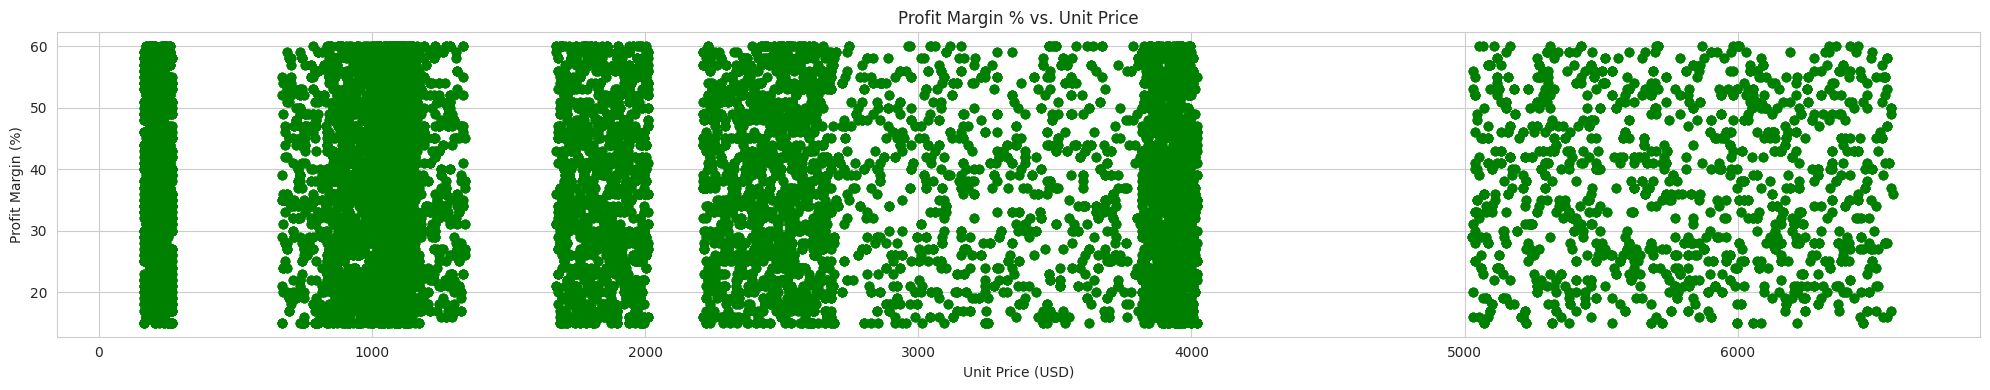

In [ ]:
# Calculate profit margin percentage for each record
df['profit_margin_pct'] = (df['profit'] / df['revenue']) * 100

plt.figure(figsize=(20,4))

plt.scatter(
    df['unit_price'],
    df['profit_margin_pct'],
    alpha=0.6,
    color='green'
)

plt.title('Profit Margin % vs. Unit Price')
plt.xlabel('Unit Price (USD)')
plt.ylabel('Profit Margin (%)')

plt.tight_layout()

plt.show()

### INSIGHTS ---

Profit margins are concentrated between ~18% and 60%, with no clear correlation to unit price, which spans from near $0 to over $6,500.

Dense horizontal bands indicate consistent margin tiers across a wide price spectrum, reflecting uniform pricing strategies.

Outliers below 18% at both low and high price points may signal cost inefficiencies or pricing issues worth deeper investigation.


## 8. *Unit Price Distribution per Product*

Goal: Compare pricing variability across different products to identify price consistency and outliers

Chart: Boxplot

EDA Type: Bivariate

Structure: Boxplot with rotated labels to display unit price spread per product

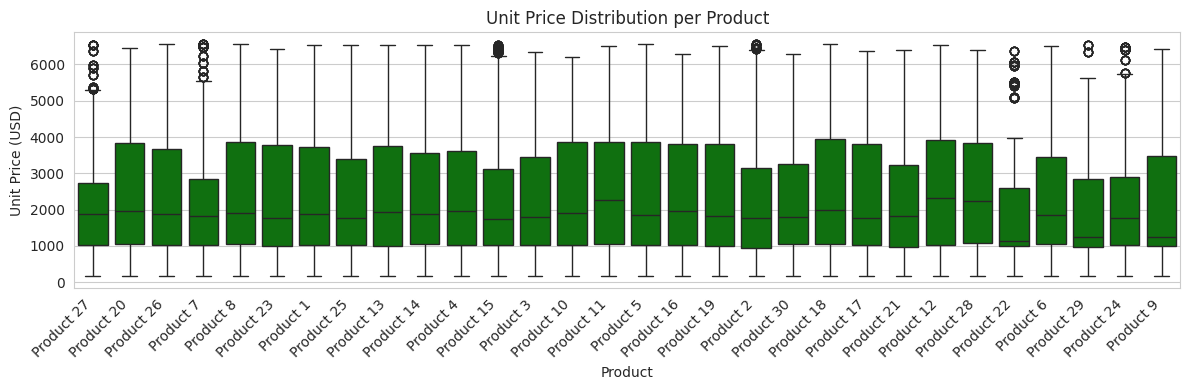

In [ ]:
plt.figure(figsize=(12,4))

sns.boxplot(
    data=df,
    x='product_name',
    y='unit_price',
    color='g',
    whis=1.5

)

plt.title('Unit Price Distribution per Product')
plt.xlabel('Product')
plt.ylabel('Unit Price (USD)')

plt.xticks(rotation=45, ha='right')

plt.tight_layout()

plt.show()

### INSIGHTS ---
Products 2,7,15,22,24,27,29 show high-end revenue spikes—well above their upper whiskers—likely due to special-edition releases, or premium bundles that temporarily inflate earnings.  

It could be due to a limited time promotion or during product release.

We can also analyse which businesses bought a these high prices and further try to upsell them our other products


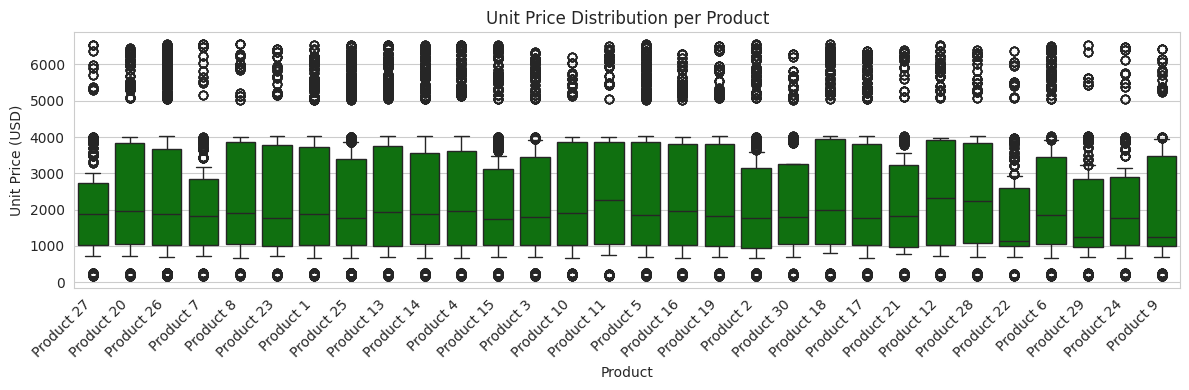

In [ ]:
plt.figure(figsize=(12,4))

sns.boxplot(
    data=df,
    x='product_name',
    y='unit_price',
    color='g',
    whis=0.2

)

plt.title('Unit Price Distribution per Product')
plt.xlabel('Product')
plt.ylabel('Unit Price (USD)')

plt.xticks(rotation=45, ha='right')

plt.tight_layout()

plt.show()

### INSIGHTS ---
In contrast, deep low-end outliers (near $0–$100) on almost all the products suggest promotional giveaways or test SKUs that pull down average prices.  

To ensure accurate margin and pricing assessments, we must exclude these outlier transactions from average calculations.  

We should check if these unusually low prices should become part of a regular promotion plan, or if they should be stopped so that our pricing stays more consistent and reliable.

## 9. *Total Sales by US Region*

**Goal:** Compare total sales across U.S. regions to identify top‑performing markets and areas for targeted growth.

**Chart:** Horizontal bar chart

**EDA Type:** Univariate comparison

**Structure:**  
- Bars sorted ascending (Northeast → West) for clear bottom‑to‑top ranking  
- X‑axis in millions USD, Y‑axis listing regions  


/tmp/ipython-input-3798319491.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


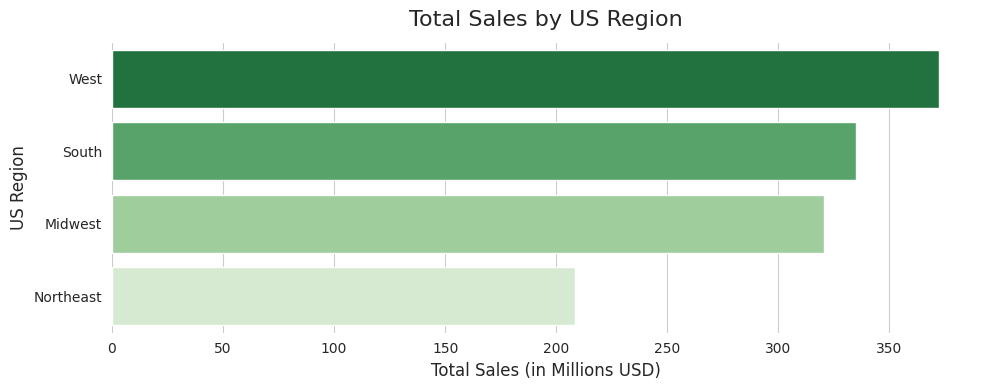

In [ ]:
region_sales =df.groupby('us_region')['revenue'].sum().sort_values(ascending=False)/ 1e6

plt.figure(figsize=(10, 4))
region_sales_df = region_sales.reset_index()

sns.barplot(
    data=region_sales_df,
    x='revenue',
    y='us_region',
    palette='Greens_r'
)

plt.title('Total Sales by US Region', fontsize=16, pad=12)
plt.xlabel('Total Sales (in Millions USD)', fontsize=12)
plt.ylabel('US Region', fontsize=12)
plt.xticks(rotation=0)
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()


### INSIGHTS —  
- **West dominates** with roughly $360 M in sales (~35 % of total), underscoring its market leadership.  
- **South & Midwest** each contribute over $320 M (~32 %), indicating strong, consistent demand across central regions.  
- **Northeast trails** at about $210 M (~20 %), signaling room for growth and targeted investment.  
- **Action:** Focus on closing the Northeast gap with local promotions and strategic partnerships, while maintaining national playbook success.  


## 10. *Total Sales by State (Choropleth Map)*

**Goal:** Visualize geographic distribution of sales to identify high- and low-performing states and uncover regional gaps.

**Chart:** US choropleth map

**EDA Type:** Univariate geospatial

**Structure:**  
- States shaded by total sales (in millions USD) using a blue gradient  
- Legend on the right showing sales scale (M USD)  
- Hover tooltips display exact sales for each state  
- Map scoped to USA for clear regional context  


In [ ]:
import plotly.express as px

# Aggregate revenue by state (in millions)
state_sales =df.groupby('state')['revenue'].sum().reset_index()

state_sales['revenue_m'] = state_sales['revenue'] / 1e6

fig = px.choropleth(
    state_sales,
    locations='state',
    locationmode='USA-states',
    color='revenue_m',
    scope='usa',
    labels={'revenue_m':'Total Sales (M USD)'},
    color_continuous_scale='Blues',
    hover_data={'revenue_m':':.2f'}
)

fig.update_layout(
    title_text='Total Sales by State',
    margin=dict(l=0, r=0, t=40, b=0),
    coloraxis_colorbar=dict(
        title='Sales (M USD)',
        ticksuffix='M'
    )
)

fig.show()


### INSIGHTS —  
- **California leads** with $230 M, followed by Illinois ($112 M) and Florida ($90 M), forming a dominant top‑tier (> $90 M).  
- **Mid‑tier states** (e.g., Texas $85 M, New York $55 M) hold steady performance but trail the top three by 40–145 M.  
- **Lower‑tier states** (e.g., New Jersey $47 M down to Massachusetts $35 M) reveal a gradual drop, indicating uneven market penetration.  
- **Action:** Double down on top states with tailored promotions, and launch targeted growth initiatives in under‑penetrated regions to close the gap.  


## 11. *Top 10 States by Revenue and Order Count*

Goal: Identify highest revenue-generating states and compare their order volumes

Chart: Two bar charts

EDA Type: Multivariate

Structure: First chart shows top 10 states by revenue (in millions), second shows top 10 states by number of orders

/tmp/ipython-input-3884583890.py:10: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipython-input-3884583890.py:21: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




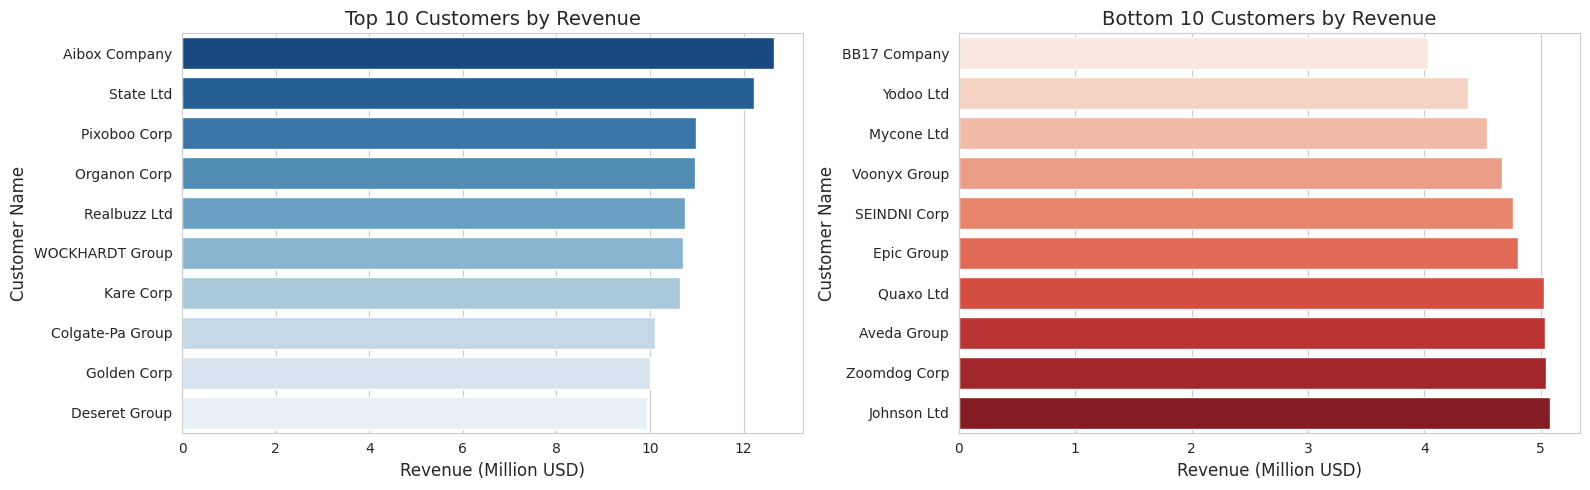

In [ ]:
# Calculate total revenue per customer and select top 10
top_rev =df.groupby('customer_name')['revenue'].sum().sort_values(ascending=False).head(10)

# Calculate total revenue per customer and select bottom 10
bottom_rev =df.groupby('customer_name')['revenue'].sum().sort_values(ascending=True).head(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: Top 10 customers by revenue
sns.barplot(
    x=top_rev.values / 1e6,
    y=top_rev.index,
    palette='Blues_r',
    ax=axes[0]
)
axes[0].set_title('Top 10 Customers by Revenue', fontsize=14)
axes[0].set_xlabel('Revenue (Million USD)', fontsize=12)
axes[0].set_ylabel('Customer Name', fontsize=12)

# Plot 2: Bottom 10 customers by revenue
sns.barplot(
    x=bottom_rev.values / 1e6,
    y=bottom_rev.index,
    palette='Reds',
    ax=axes[1]
)
axes[1].set_title('Bottom 10 Customers by Revenue', fontsize=14)
axes[1].set_xlabel('Revenue (Million USD)', fontsize=12)
axes[1].set_ylabel('Customer Name', fontsize=12)

plt.tight_layout()
plt.show()

### INSIGHTS ---
- Aibox Company tops the list with $12.5 M, followed closely by State Ltd ($12.2 M), while the 10th-ranked Deseret Group still contributes $9.9 M—demonstrating a tight $10–12 M top tier.

- At the bottom, Johnson Ltd leads its group with $5.1 M, down to BB17 Company at $4.1 M—roughly half the top customer’s revenue.

- This steep drop from ~$10 M+ to $4–5 M highlights high revenue concentration among the top customers.

- Action: prioritize retention and upsell for your top ten, and launch targeted growth campaigns to elevate the lower-revenue cohort.


## 12. *Average Profit Margin by Channel*

Goal: Compare average profit margins across sales channels to identify the most and least profitable routes

Chart: Bar chart

EDA Type: Bivariate

Structure: Vertical bars with data labels showing margin percentages, sorted descending by channel

/tmp/ipython-input-2926512133.py:6: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




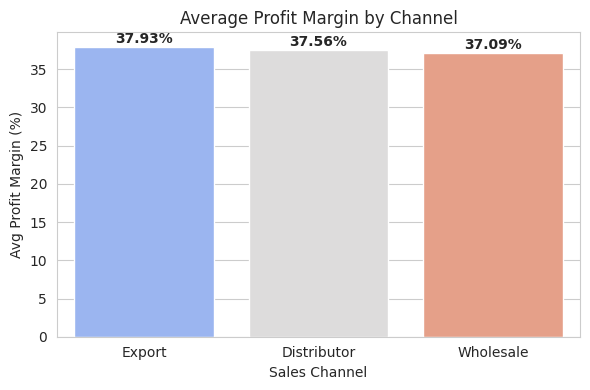

In [ ]:
# Compute average profit margin percentage for each channel
channel_margin =df.groupby('channel')['profit_margin_pct'].mean().sort_values(ascending=False)

plt.figure(figsize=(6, 4))
channel_margin_df = channel_margin.reset_index()
ax = sns.barplot(
    data=channel_margin_df,
    x='channel',
    y='profit_margin_pct',
    palette='coolwarm'
)

plt.title('Average Profit Margin by Channel')
plt.xlabel('Sales Channel')
plt.ylabel('Avg Profit Margin (%)')

for i, v in enumerate(channel_margin.values):
    ax.text(
        i,
        v + 0.5,
        f"{v:.2f}%",
        ha='center',
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

### INSIGHTS ---
Export leads with a 37.93 % average margin, closely followed by Distributor (37.56 %) and Wholesale (37.09 %).  

The tiny spread (< 0.2 %) shows consistently strong profitability across all channels.  

This uniformity implies well-controlled costs and pricing power everywhere.  

To maximize returns, push volume growth in Export while maintaining efficiency in Distributor and Wholesale.  

## 13. *Top and Bottom 10 Customers by Revenue*

Goal: Identify your highest- and lowest-revenue customers to tailor engagement strategies

Chart: Side-by-side horizontal bar charts

EDA Type: Multivariate

Structure: Left chart shows top 10 customers by revenue (in millions), right chart shows bottom 10 customers by revenue (in millions)

/tmp/ipython-input-3017203514.py:9: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




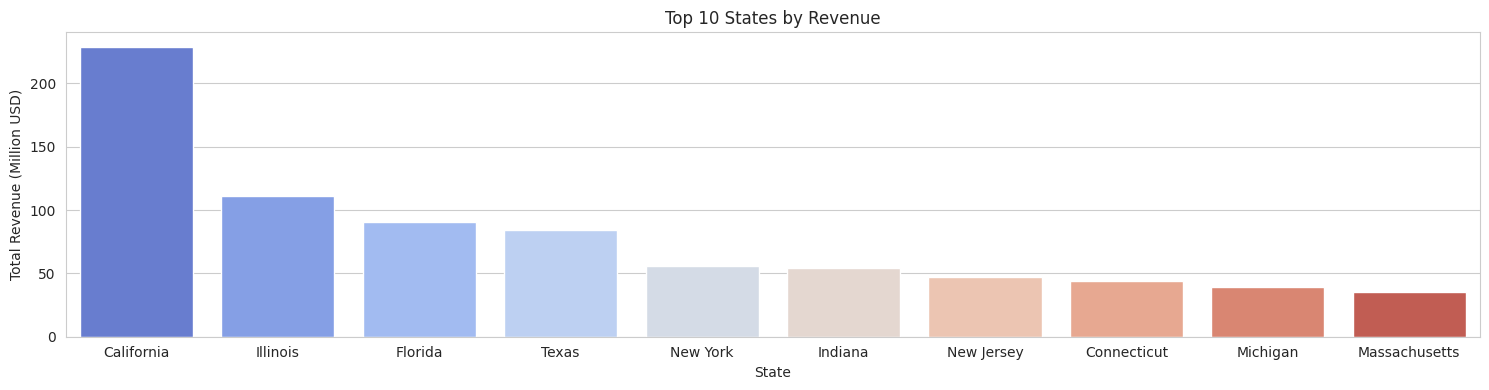

/tmp/ipython-input-3017203514.py:22: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




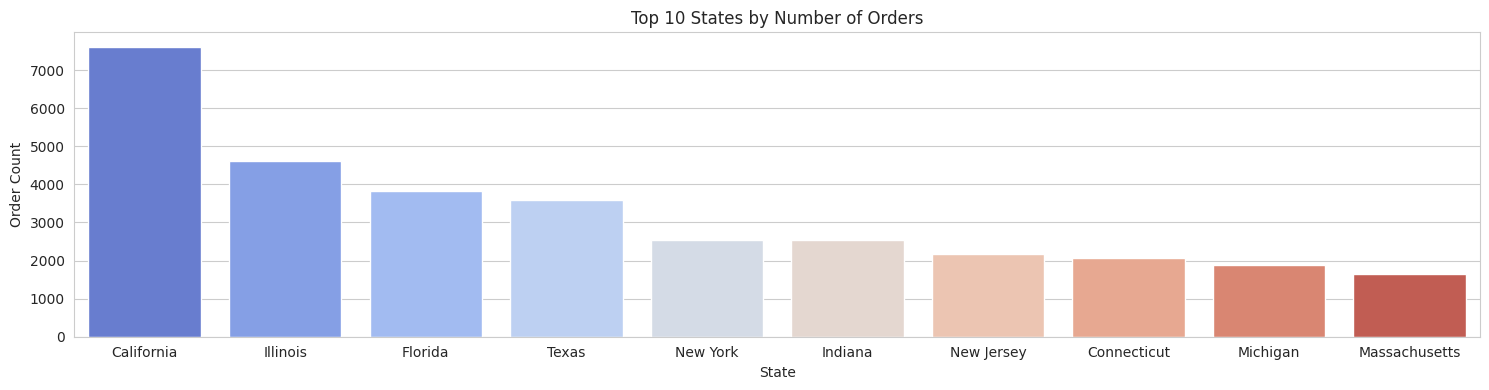

In [ ]:
# Aggregate total revenue and unique order count per state
state_rev = df.groupby('state_name').agg(
    revenue=('revenue', 'sum'),
    orders=('order_number', 'nunique')
).sort_values('revenue', ascending=False).head(10)

# Plot 1: Top 10 states by revenue (scaled to millions)
plt.figure(figsize=(15, 4))
sns.barplot(
    x=state_rev.index,
    y=state_rev['revenue'] / 1e6,
    palette='coolwarm'
)
plt.title('Top 10 States by Revenue')
plt.xlabel('State')
plt.ylabel('Total Revenue (Million USD)')
plt.tight_layout()
plt.show()

# Plot 2: Top 10 states by number of orders
plt.figure(figsize=(15, 4))
sns.barplot(
    x=state_rev.index,
    y=state_rev['orders'],
    palette='coolwarm'
)
plt.title('Top 10 States by Number of Orders')
plt.xlabel('State')
plt.ylabel('Order Count')
plt.tight_layout()
plt.show()

### INSIGHTS ---
California leads by a wide margin, generating about \$230 M in revenue and 7500 orders—more than twice the next-highest state.  

Illinois, Florida, and Texas form a solid second tier, each posting $85–110 M in revenue with 3 600–4 600 orders.  

New York and Indiana are mid-pack (≈$54–55 M, ~2 500 orders), while Connecticut, Michigan, and Massachusetts trail at $35–44 M with 1 600–2 100 orders.  

The close alignment between revenue and order counts suggests similar average order values across states; to drive growth, focus on increasing order volume in the mid-tier and raising order size in lower-performing regions.  

## 14. *Customer Segmentation: Revenue vs. Profit Margin*

Goal: Segment customers by total revenue and average profit margin, highlighting order volume

Chart: Bubble chart (scatter plot with variable point sizes)

EDA Type: Multivariate

Structure: Scatter points sized by number of orders, plotting revenue vs. margin

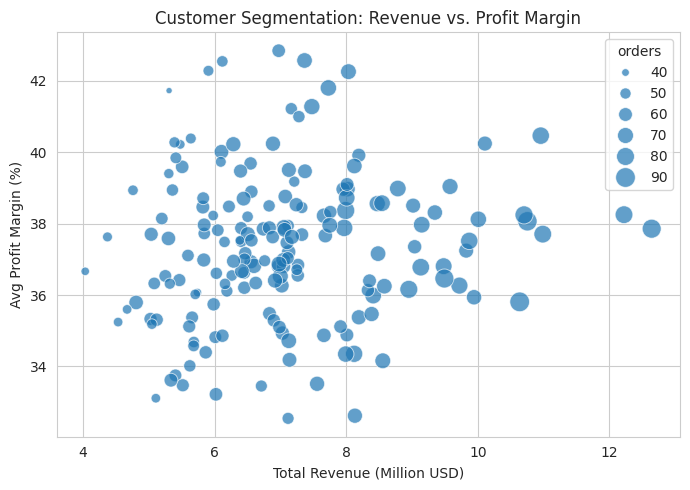

In [ ]:
# Aggregate metrics per customer
cust_summary = df.groupby('customer_name').agg(
    total_revenue=('revenue', 'sum'),
    avg_margin=('profit_margin_pct', 'mean'),
    orders=('order_number', 'nunique')
)

cust_summary['total_revenue_m'] = cust_summary['total_revenue'] / 1e6

plt.figure(figsize=(7, 5))

# Bubble chart with revenue in millions
sns.scatterplot(
    data=cust_summary,
    x='total_revenue_m',
    y='avg_margin',
    size='orders',
    sizes=(20, 200),
    alpha=0.7
)

plt.title('Customer Segmentation: Revenue vs. Profit Margin')
plt.xlabel('Total Revenue (Million USD)')
plt.ylabel('Avg Profit Margin (%)')

plt.tight_layout()
plt.show()


### INSIGHTS ---

- Customers with > $10 M in revenue tend to sustain margins between 36–40%, indicating that scale does not significantly erode profitability.
- Most customers cluster within the $6–10 M range and show stable margins (~34–40%), suggesting consistent pricing in this tier.
- Customers below $6 M display the widest margin variance (~33–43%), pointing to more volatile cost structures or discounts among smaller accounts.
- Bubble size (order count) increases with revenue, but margin levels appear unaffected—reinforcing revenue as the dominant performance driver over order volume.


## 15. *Correlation Heatmap of Numeric Features*

Goal: Identify relationships among key numeric variables to uncover potential multicollinearity

Chart: Correlation heatmap

EDA Type: Multivariate

Structure: Annotated heatmap with correlation coefficients for selected numeric columns

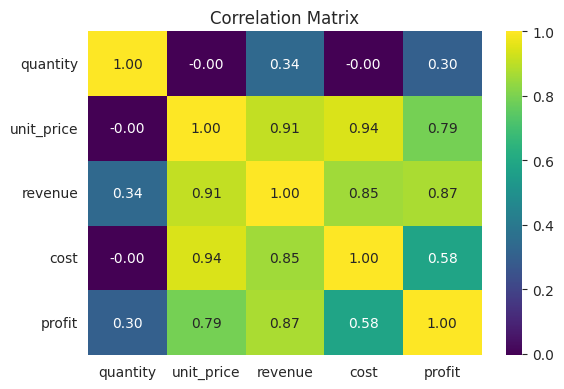

In [ ]:
num_cols = ['quantity', 'unit_price', 'revenue', 'cost', 'profit']

corr = df[num_cols].corr()

plt.figure(figsize=(6,4))

# Plot the heatmap with annotations and a viridis colormap
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap='viridis'
)

plt.title('Correlation Matrix')

plt.tight_layout()

plt.show()

### INSIGHTS ---
- **Profit and revenue** are very strongly correlated (0.87), indicating that as sales value increases, profit tends to rise as well.  
- **Unit price** is a key driver: it correlates 0.91 with revenue, 0.79 with profit, and 0.94 with cost—highlighting how pricing decisions ripple through both top‑line and expense figures.  
- **Cost** shows a strong link to revenue (0.85) but a more moderate tie to profit (0.58), underscoring that while higher sales often bring higher expenses, margins can still vary.  
- **Quantity** has virtually no correlation with unit price or cost (≈0.00) and only modest associations with revenue (0.34) and profit (0.30), making volume a secondary factor compared to pricing.  


# **Saving Pre-Processed Dataframe**

In [ ]:
df

,order_number,order_date,customer_name,channel,product_name,quantity,unit_price,revenue,cost,state,...,us_region,lat,lon,budget,total_cost,profit,profit_margin_pct,order_month_name,order_month_num,order_month
0,SO - 000225,2018-01-01,Rhynoodle Ltd,Wholesale,Product 27,6,2499.1,14994.6,1824.343,GA,...,South,32.08354,-81.09983,NaN,10946.058,4048.542,27.0,January,1,2018-01
1,SO - 0003378,2018-01-01,Thoughtmix Ltd,Distributor,Product 20,11,2351.7,25868.7,1269.918,IN,...,Midwest,39.61366,-86.10665,NaN,13969.098,11899.602,46.0,January,1,2018-01
2,SO - 0005126,2018-01-01,Amerisourc Corp,Wholesale,Product 26,6,978.2,5869.2,684.740,CA,...,West,37.66243,-121.87468,NaN,4108.440,1760.760,30.0,January,1,2018-01
3,SO - 0005614,2018-01-01,Colgate-Pa Group,Export,Product 7,7,2338.3,16368.1,1028.852,IN,...,Midwest,39.16533,-86.52639,NaN,7201.964,9166.136,56.0,January,1,2018-01
4,SO - 0005781,2018-01-01,Deseret Group,Wholesale,Product 8,8,2291.4,18331.2,1260.270,CT,...,Northeast,41.77524,-72.52443,NaN,10082.160,8249.040,45.0,January,1,2018-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64099,SO - 0007573,2022-02-28,Dazzlesphe Corp,Wholesale,Product 26,12,1815.7,21788.4,980.478,PA,...,Northeast,40.15511,-74.82877,NaN,11765.736,10022.664,46.0,February,2,2022-02
64100,SO - 0007706,2022-02-28,Yombu Corp,Export,Product 21,6,864.3,5185.8,579.081,IL,...,Midwest,42.11030,-88.03424,NaN,3474.486,1711.314,33.0,February,2,2022-02
64101,SO - 0007718,2022-02-28,Bath Group,Distributor,Product 13,11,3953.0,43483.0,2648.510,FL,...,South,26.24453,-80.20644,NaN,29133.610,14349.390,33.0,February,2,2022-02
64102,SO - 0008084,2022-02-28,Linklinks Ltd,Distributor,Product 20,7,3959.7,27717.9,2930.178,NY,...,Northeast,42.91002,-78.74182,NaN,20511.246,7206.654,26.0,February,2,2022-02


In [ ]:
df.to_csv('Sales_data(EDA Exported).csv', index=False)

# **Key Insights**  



- **Monthly Revenue Cycle:**  
  Revenue stays stable between ≈$23M–$26.5M across 2018–2021, with no consistent seasonal spikes. Sharpest drop (≈$21.2M) occurs in early 2021, indicating a possible one-time disruption.

- **Channel Mix:**  
  Wholesale: 54%. Distributors: 31%. Exports: 15% — opportunity to scale international presence.

- **Top Products (Revenue):**  
  Product 26: $118M; Product 25: $110M; Product 13: $78M. Mid-tier: $68–75M; bottom performers: $52–57M.

- **Profit Margins:**  
  Profit margins range broadly from ≈18% to ≈60%, with no strong correlation to unit price. Dense horizontal bands suggest standardized pricing strategies across tiers.

- **Seasonal Volume:**  
  No strong monthly pattern, but slight volume uptick appears around May–June. Early 2021 dip (≈$21.2M) may require investigation.

- **Regional Performance:**  
  California leads: ≈$230M Revenue & 7500+ orders. Illinois/Florida/Texas: ≈$85M–$110M & ≈3500–4500 orders.

